# 02 Data Cleaning and Feature Engineering

What we learned from EDA:

- **Name** - Not useful to analysis, drop column
- **Sex** - Alter to numerical values (0 or 1)
- **Age** - Proportion of data missing 177/891=0.199, impute on median
- **Ticket** - Note useful to analysis, drop column
- **Cabin** - Proportion of data missing 687/891=0.782, drop column
- **Embarked** - Proportion of data missing, impute on mode

## 1. Import Libraries and Load Data

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/train.csv") # training data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Handle Missing Values

In [62]:
# Create a new dataframe containing the sum of missing values, along with
# the percentage of missing values
missing_vals = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
# Remove all rows without missing values, then sort according to the
# missing value percentage
missing_vals = missing_vals[missing_vals["Missing Count"] > 0].sort_values("Missing %", ascending=False)
# Print the final result
missing_vals

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


- **Name** - Not useful to analysis, drop column
- **Sex** - Alter to numerical values (0 or 1)
- **Age** - Proportion of data missing 177/891=0.199, impute on median
- **Ticket** - Note useful to analysis, drop column
- **Cabin** - Proportion of data missing 687/891=0.782, drop column
- **Embarked** - Proportion of data missing, impute on mode

### 2.1 Drop [Name, Ticket, Cabin]

In [63]:
df_cleaned = df.drop(columns=["Name","Ticket","Cabin"])
df_cleaned.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


### 2.2 Alter Sex to Numerical Values
Map male to 0 and female to 1.

In [64]:
df_cleaned["Sex"] = df_cleaned["Sex"].map({"male": 0, "female": 1})

### 2.3 Impute Age on Median
Could do this more fine-grained by imputing the age in distinct classes, but for now this will do.

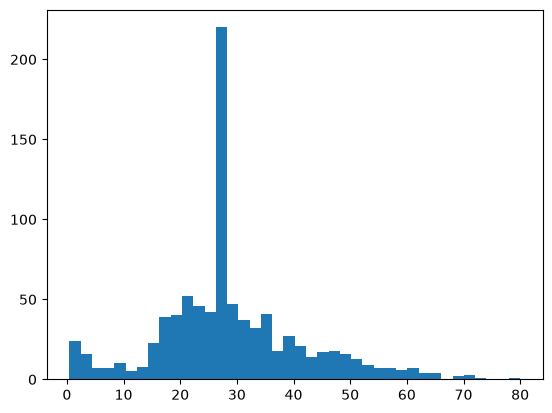

In [65]:
df_cleaned["Age"] = df_cleaned["Age"].fillna(df_cleaned["Age"].median())
plt.hist(df_cleaned["Age"], bins=40)
plt.show()

### 2.6 Impute Embarked on Mode

In [66]:
df_cleaned["Embarked"] = df_cleaned["Embarked"].fillna(df_cleaned["Embarked"].mode()[0])
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(2), int64(6), str(1)
memory usage: 62.8 KB


## 3. Engineer Features


### 3.1 Age Groups
We noted in the EDA that young people have a higher survival rate, so we create a new feature that encodes age categories.

In [67]:
df_cleaned["AgeGroup"] = pd.cut(df_cleaned["Age"], 
                        bins=[0, 10, 18, 40, 60, 80],
                       labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

### 3.2 Family Size
We found that the total family size was correlated with survival in a non-trivial way.

In [68]:
df_cleaned["Fam"] = df_cleaned["Parch"] + df_cleaned["SibSp"]

In [69]:
df_cleaned.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,Fam
0,1,0,3,0,22.0,1,0,7.2500,S,Young Adult,1
1,2,1,1,1,38.0,1,0,71.2833,C,Young Adult,1
2,3,1,3,1,26.0,0,0,7.9250,S,Young Adult,0
3,4,1,1,1,35.0,1,0,53.1000,S,Young Adult,1
4,5,0,3,0,35.0,0,0,8.0500,S,Young Adult,0
5,6,0,3,0,28.0,0,0,8.4583,Q,Young Adult,0
6,7,0,1,0,54.0,0,0,51.8625,S,Adult,0
7,8,0,3,0,2.0,3,1,21.0750,S,Child,4
8,9,1,3,1,27.0,0,2,11.1333,S,Young Adult,2
9,10,1,2,1,14.0,1,0,30.0708,C,Teen,1


## 4. Encode Categorical Variables
Our only categorical variable is Embarked, which we can use get_dummies to encode into a onehot variable by splitting it into three distinct columns. Note we also drop_first, to avoid redundancy, meaning any model without a 1 in the Embarked_Q or Embarked_S is considered as Embarked_C.

In [70]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["Embarked", "AgeGroup"], drop_first=True, dtype=int)
df_cleaned.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,0,22.0,1,0,7.2500,1,0,1,0,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,1,0,0,0,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1,0,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,1,0,1,0,1,0,0
4,5,0,3,0,35.0,0,0,8.0500,0,0,1,0,1,0,0


## 5. Save and Summarise

In [72]:
df_cleaned.to_csv("data/titanic_cleaned.csv", index=False)

|Step|Action|
|-|-|
|Name| Dropped|
|Ticket| Dropped|
|Cabin| Dropped|
|Sex| Encoded to male=0, female=1|
|Age| Imputed on median|
|Embarked|Imputed on mode|
|AgeGroups| Feature created by grouping ages into age epochs|
|Fam| Created total family size feature|
|Encoding| Encoded Embarked and AgeGroup into onehot variable|